In [1]:
import os
from google.colab import userdata
import pandas as pd


os.environ["KAGGLE_API_TOKEN"] = userdata.get('KAGGLE_API_TOKEN')

!pip install -q kaggle

!kaggle datasets download -d thedevastator/airbnb-listings-in-london-neighbourhoods-and-rev
!unzip -o airbnb-listings-in-london-neighbourhoods-and-rev.zip

airbnb_listings = pd.read_csv("listings.csv")

!kaggle datasets download -d marshald/london-boroughs
!unzip -o london-boroughs.zip

london_boroughs = pd.read_csv("london-borough-profiles-2016 Data set.csv")

Dataset URL: https://www.kaggle.com/datasets/thedevastator/airbnb-listings-in-london-neighbourhoods-and-rev
License(s): CC0-1.0
100% 11.0M/11.0M [00:00<00:00, 54.0MB/s]

Archive:  airbnb-listings-in-london-neighbourhoods-and-rev.zip
  inflating: listings.csv            
  inflating: neighbourhoods.csv      
  inflating: neighbourhoods.geojson  
  inflating: reviews.csv             
Dataset URL: https://www.kaggle.com/datasets/marshald/london-boroughs
License(s): DbCL-1.0
100% 9.90k/9.90k [00:00<00:00, 23.7MB/s]

Archive:  london-boroughs.zip
  inflating: london-borough-profiles-2016 Data set.csv  


In [2]:
# Airbnb Pressure Score

# Keep only borough name and household estimates from borough dataset
# Household estimates are needed to normalize Airbnb listings by borough size
demographics = london_boroughs[[
    "Area name",
    "GLA Household Estimate 2016"
]].copy()

demographics.columns = [
    "borough",
    "household_estimate"
]

demographics["household_estimate"] = (
    demographics["household_estimate"]
    .astype(str)
    .str.replace(",", "")
)

demographics["household_estimate"] = pd.to_numeric(
    demographics["household_estimate"],
    errors="coerce"
)

# Remove rows with missing borough names or household estimates
demographics = demographics.dropna(subset=["borough", "household_estimate"])

print(demographics.head())

                borough  household_estimate
1        City of London              5179.0
2  Barking and Dagenham             76841.0
3                Barnet            149147.0
4                Bexley             97233.0
5                 Brent            119166.0


In [3]:
# Airbnb Pressure Score

borough_airbnb = pd.DataFrame()

# Total number of Airbnb listings in a borough
# More listings -> potentially more Airbnb pressure
borough_airbnb["listing_count"] = (
    airbnb_listings.groupby("neighbourhood")
    .size()
)

# Percentage of listings that are entire homes/apartments
# Entire homes reduce long-term housing supply
# Higher -> more housing pressure
borough_airbnb["entire_home_share"] = (
    airbnb_listings.groupby("neighbourhood")["room_type"]
    .apply(lambda x: (x == "Entire home/apt").mean())
)

# Average number of days listings are available each year
# High availability -> listings may behave more like commercial rentals
borough_airbnb["avg_availability"] = (
    airbnb_listings.groupby("neighbourhood")["availability_365"]
    .mean()
)

# Share of listings belonging to hosts with more than 3 listings
# Higher values suggest stronger Airbnb commercialization
borough_airbnb["multi_host_share"] = (
    airbnb_listings.groupby("neighbourhood")["calculated_host_listings_count"]
    .apply(lambda x: (x > 3).mean())
)

# Merge Airbnb indicators with borough household estimates
# Uses borough name as the joining key
borough_airbnb = borough_airbnb.merge(
    demographics,
    left_index=True,
    right_on="borough",
    how="left"
)

# Number of Airbnb listings per 1000 households
# Normalizes listing count to account for borough size
# Makes boroughs more comparable than raw listing counts
borough_airbnb["listing_density"] = (
    borough_airbnb["listing_count"]
    /
    borough_airbnb["household_estimate"]
) * 1000

# Check for boroughs that failed to merge
# Empty output means all boroughs matched successfully
print(
    borough_airbnb[
        borough_airbnb["household_estimate"].isna()
    ]
)

borough_airbnb.head()

Empty DataFrame
Columns: [listing_count, entire_home_share, avg_availability, multi_host_share, borough, household_estimate, listing_density]
Index: []


,listing_count,entire_home_share,avg_availability,multi_host_share,borough,household_estimate,listing_density
2,337,0.311573,162.278932,0.089021,Barking and Dagenham,76841.0,4.385680
3,1577,0.420419,135.965124,0.169943,Barnet,149147.0,10.573461
4,238,0.273109,177.668067,0.155462,Bexley,97233.0,2.447729
5,2472,0.473301,129.059871,0.281958,Brent,119166.0,20.744172
6,674,0.427300,170.562315,0.186944,Bromley,139654.0,4.826213


In [4]:
# Show boroughs with highest Airbnb density
borough_airbnb[
    [
        "borough",
        "listing_count",
        "household_estimate",
        "listing_density"
    ]
].sort_values(
    "listing_density",
    ascending=False
).head(10)

,borough,listing_count,household_estimate,listing_density
1,City of London,466,5179.0,89.978760
33,Westminster,9411,117509.0,80.087483
20,Kensington and Chelsea,5852,79735.0,73.393115
30,Tower Hamlets,8024,120576.0,66.547240
7,Camden,5968,106518.0,56.028089
12,Hackney,6116,113537.0,53.867902
13,Hammersmith and Fulham,4209,82513.0,51.010144
19,Islington,5156,103612.0,49.762576
28,Southwark,4886,132080.0,36.992732
22,Lambeth,4807,142382.0,33.761290


In [5]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA

# Variables used to define Airbnb pressure
vars_for_pca = [
    "listing_density",
    "entire_home_share",
    "avg_availability",
    "multi_host_share"
]

# Remove boroughs with missing values
pca_data = borough_airbnb.dropna(
    subset=vars_for_pca
).copy()

# Standardize variables
scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    pca_data[vars_for_pca]
)

# Run PCA
# First principal component captures maximum variance
pca = PCA(n_components=1)

pca_scores = pca.fit_transform(X_scaled)

# Add raw PCA score
pca_data["airbnb_pressure_raw"] = pca_scores[:,0]

# Inspect PCA weights
weights = pd.Series(
    pca.components_[0],
    index=vars_for_pca
)

print("PCA weights:")
print(weights)

print("\nExplained variance:")
print(pca.explained_variance_ratio_[0])

PCA weights:
listing_density      0.594060
entire_home_share    0.586582
avg_availability    -0.189619
multi_host_share     0.516777
dtype: float64

Explained variance:
0.6719847762568681


In [6]:
# Flip sign so higher score = higher pressure
if weights["listing_density"] < 0:
    pca_data["airbnb_pressure_raw"] *= -1

# Normalize to 0–1
minmax = MinMaxScaler()

pca_data["airbnb_pressure_score"] = (
    minmax.fit_transform(
        pca_data[["airbnb_pressure_raw"]]
    )
)

# Convert to categories
pca_data["airbnb_pressure_level"] = pd.qcut(
    pca_data["airbnb_pressure_score"],
    q=3,
    labels=["Low","Medium","High"]
)


# Inspect highest pressure boroughs
top_pressure = pca_data[
    [
        "borough",
        "airbnb_pressure_score",
        "airbnb_pressure_level"
    ]
].sort_values(
    "airbnb_pressure_score",
    ascending=False
)

print(top_pressure.head(10))

                   borough  airbnb_pressure_score airbnb_pressure_level
1           City of London               1.000000                  High
33             Westminster               0.857519                  High
20  Kensington and Chelsea               0.842916                  High
7                   Camden               0.667386                  High
30           Tower Hamlets               0.580011                  High
13  Hammersmith and Fulham               0.578327                  High
19               Islington               0.529733                  High
12                 Hackney               0.445091                  High
28               Southwark               0.414116                  High
32              Wandsworth               0.392755                  High


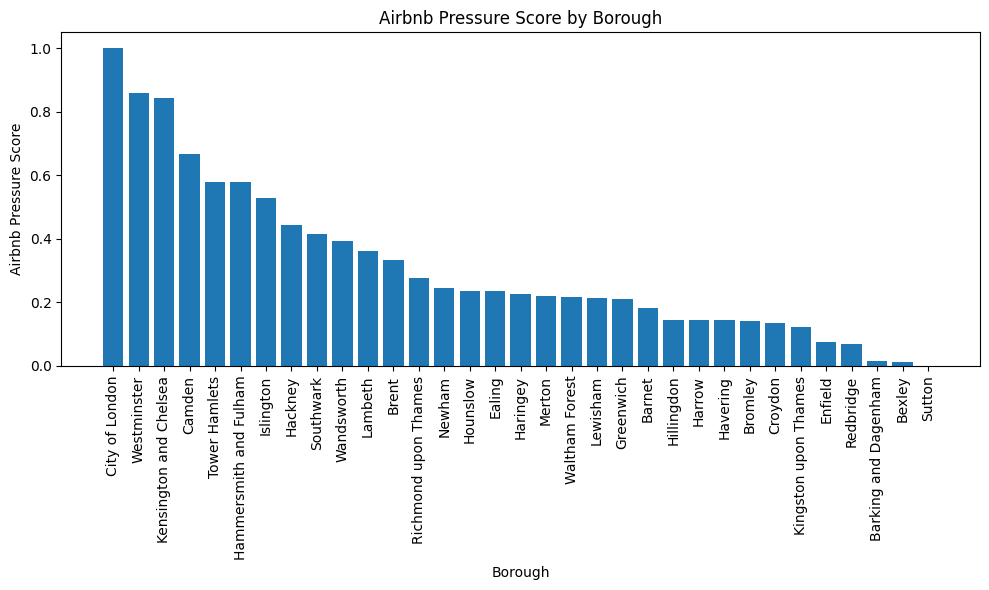

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(
    top_pressure["borough"],
    top_pressure["airbnb_pressure_score"]
)

plt.xticks(rotation=90)

plt.xlabel("Borough")
plt.ylabel("Airbnb Pressure Score")

plt.title("Airbnb Pressure Score by Borough")

plt.tight_layout()
plt.show()

In [8]:
# Housing Pressure Score

# Keep only variables relevant to housing pressure
housing = london_boroughs[[
    "Area name",
    "Median House Price, 2014",
    "Modelled Household median income estimates 2012/13",
    "Population density (per hectare) 2016",
    "Rented from Private landlord, (2014) %",
    "New Homes (net) 2014/15 (provisional)"
]].copy()

# Rename columns for easier handling
housing.columns = [
    "borough",
    "median_house_price",
    "median_income",
    "population_density",
    "private_rent_share",
    "new_homes"
]

# Convert string values to numeric
numeric_cols = [
    "median_house_price",
    "median_income",
    "population_density",
    "private_rent_share",
    "new_homes"
]

for col in numeric_cols:

    housing[col] = (
        housing[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("£", "", regex=False)
        .str.replace("%", "", regex=False)
        .str.strip()
    )

    housing[col] = pd.to_numeric(
        housing[col],
        errors="coerce"
    )

# Remove rows with missing important values
housing = housing.dropna(
    subset=[
        "borough",
        "median_house_price",
        "median_income",
        "population_density",
        "private_rent_share",
        "new_homes"
    ]
)

# Affordability indicator
# Higher ratio -> housing less affordable -> stronger pressure
housing["price_income_ratio"] = (
    housing["median_house_price"]
    /
    housing["median_income"]
)

# Reverse housing supply
# More new homes -> lower pressure
# Fewer new homes -> higher pressure
housing["low_new_homes_pressure"] = (
    -housing["new_homes"]
)

# Inspect processed data
housing.head()

# note: there's no city of london because private_rent_share is NaN

,borough,median_house_price,median_income,population_density,private_rent_share,new_homes,price_income_ratio,low_new_homes_pressure
2,Barking and Dagenham,215000.0,34080.0,57.3,20.3,510.0,6.308685,-510.0
3,Barnet,400000.0,54530.0,44.5,31.1,1320.0,7.335412,-1320.0
4,Bexley,250000.0,44430.0,39.9,11.4,810.0,5.626829,-810.0
5,Brent,385000.0,39630.0,76.1,34.8,1560.0,9.714862,-1560.0
6,Bromley,335000.0,55140.0,21.7,14.1,410.0,6.075444,-410.0


In [9]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA

# Variables defining housing pressure
vars_for_pca = [
    "price_income_ratio",
    "population_density",
    "private_rent_share",
    "low_new_homes_pressure"
]

# Remove missing values
housing_pca = housing.dropna(
    subset=vars_for_pca
).copy()

# Standardize variables
scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    housing_pca[vars_for_pca]
)

pca = PCA(n_components=1)

housing_scores = pca.fit_transform(
    X_scaled
)

# Add raw PCA score
housing_pca["housing_pressure_raw"] = (
    housing_scores[:,0]
)

# Inspect weights
weights = pd.Series(
    pca.components_[0],
    index=vars_for_pca
)

print("PCA weights:")
print(weights)

print("\nExplained variance:")
print(pca.explained_variance_ratio_[0])

PCA weights:
price_income_ratio        0.614154
population_density        0.581244
private_rent_share        0.532650
low_new_homes_pressure    0.035426
dtype: float64

Explained variance:
0.589401700358341


In [10]:
# Flip sign if needed
if weights["price_income_ratio"] < 0:
    housing_pca["housing_pressure_raw"] *= -1

# Normalize to 0–1
minmax = MinMaxScaler()

housing_pca["housing_pressure_score"] = (
    minmax.fit_transform(
        housing_pca[["housing_pressure_raw"]]
    )
)

# Create levels
housing_pca["housing_pressure_level"] = pd.qcut(
    housing_pca["housing_pressure_score"],
    q=3,
    labels=["Low","Medium","High"]
)

# Inspect highest pressure boroughs
top_housing = housing_pca[
    [
        "borough",
        "housing_pressure_score",
        "housing_pressure_level"
    ]
].sort_values(
    "housing_pressure_score",
    ascending=False
)

print(top_housing)

                   borough  housing_pressure_score housing_pressure_level
33             Westminster                1.000000                   High
20  Kensington and Chelsea                0.878267                   High
13  Hammersmith and Fulham                0.847589                   High
19               Islington                0.800076                   High
7                   Camden                0.786870                   High
30           Tower Hamlets                0.775950                   High
12                 Hackney                0.774577                   High
22                 Lambeth                0.754533                   High
5                    Brent                0.714283                   High
25                  Newham                0.684452                   High
34            Inner London                0.627363                   High
28               Southwark                0.623616                   High
32              Wandsworth            

In [11]:
pressure = pd.merge(
    pca_data[[
        "borough",
        "airbnb_pressure_score"
    ]],

    housing_pca[[
        "borough",
        "housing_pressure_score"
    ]],

    on="borough"
)

print(pressure)

                   borough  airbnb_pressure_score  housing_pressure_score
0     Barking and Dagenham               0.016043                0.229112
1                   Barnet               0.183350                0.407404
2                   Bexley               0.013783                0.016798
3                    Brent               0.332330                0.714283
4                  Bromley               0.143056                0.035180
5                   Camden               0.667386                0.786870
6                  Croydon               0.134864                0.139084
7                   Ealing               0.234598                0.594261
8                  Enfield               0.075889                0.237566
9                Greenwich               0.209563                0.285550
10                 Hackney               0.445091                0.774577
11  Hammersmith and Fulham               0.578327                0.847589
12                Haringey            

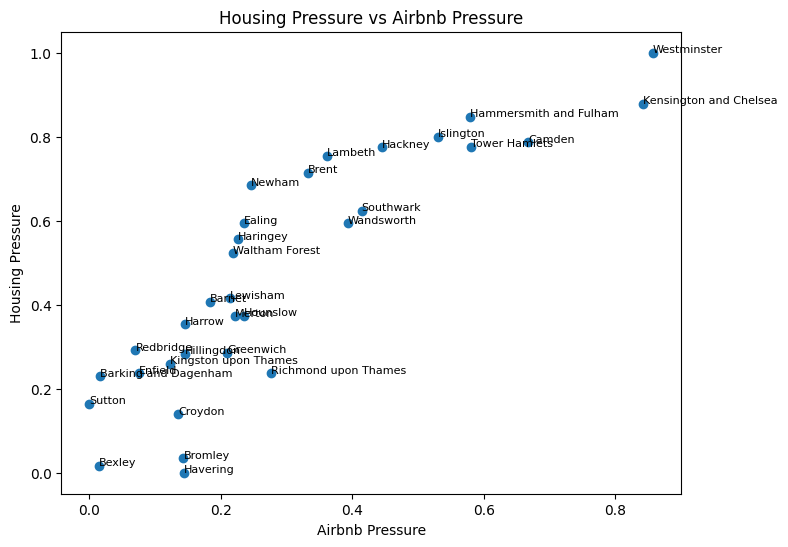

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    pressure["airbnb_pressure_score"],
    pressure["housing_pressure_score"]
)

for i, row in pressure.iterrows():
    plt.text(
        row["airbnb_pressure_score"],
        row["housing_pressure_score"],
        row["borough"],
        fontsize=8
    )

plt.xlabel("Airbnb Pressure")
plt.ylabel("Housing Pressure")
plt.title("Housing Pressure vs Airbnb Pressure")

plt.show()